In [3]:
import sys, os

import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
root = Path.cwd().parents[1]
sys.path.extend([str(root), str(root / 'plotting')])

from im_net import plotting
import datareader

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plot_path = "../figures/appendix/correlations"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

paper_palette = ['#1a1a1aff', '#d0a807ff', '#406ee1ff', '#c93b9bff', '#1dbd68ff']

alpha_h   = 0.14
alpha_red = 1.59

## Data Loading

Memory capacity $\alpha_c$ as a function of input correlation $p$ (Bernoulli parameter),
for infomorphic (Panel A) and Hebbian (Panel B) networks.

**Training commands:**
```bash
# Infomorphic
python src/training.py -m +mods/capacity=correlation \
    dataset.correlation=spatial dataset.p_bernoulli='range(0.5,0.9,0.05)' \
    params.epochs=5000 params.pref_gpu=False params.seed='range(20)' storage=cluster

# Hebbian
python src/training.py +mods/capacity=correlation \
    dataset.correlation=spatial dataset.p_bernoulli='range(0.5,0.9,0.05)' \
    params.epochs=5000 params.pref_gpu=False params.seed='range(20)' storage=cluster
```

In [ ]:
# TODO: set paths to correlation experiment folders
correlation_file = ''
hebb_file        = ''

dm_cor,  _, _, labels_cor  = datareader.load_capacity_runs(correlation_file, 'dataset.p_bernoulli')
dm_hebb, _, _, labels_hebb = datareader.load_capacity_runs(hebb_file,        'dataset.p_bernoulli')

n_reps = len(set(dm_cor.sel['params.seed']))

x_corr    = np.array(labels_cor).reshape((-1, n_reps))[:, 0]
alpha_max = np.array(dm_cor.sel['m_max']).reshape((-1, n_reps)) / 100

x_corr4    = np.array(labels_hebb).reshape((-1, n_reps))[:, 0]
alpha_max4 = np.array(dm_hebb.sel['m_max']).reshape((-1, n_reps)) / 100

print(f"Correlation values: {x_corr}")
print(f"Seeds: {n_reps}, capacity shape: {alpha_max.shape}")

Correlation values: [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85]
Seeds: 20, capacity shape: (8, 20)


## Capacity vs. Correlation

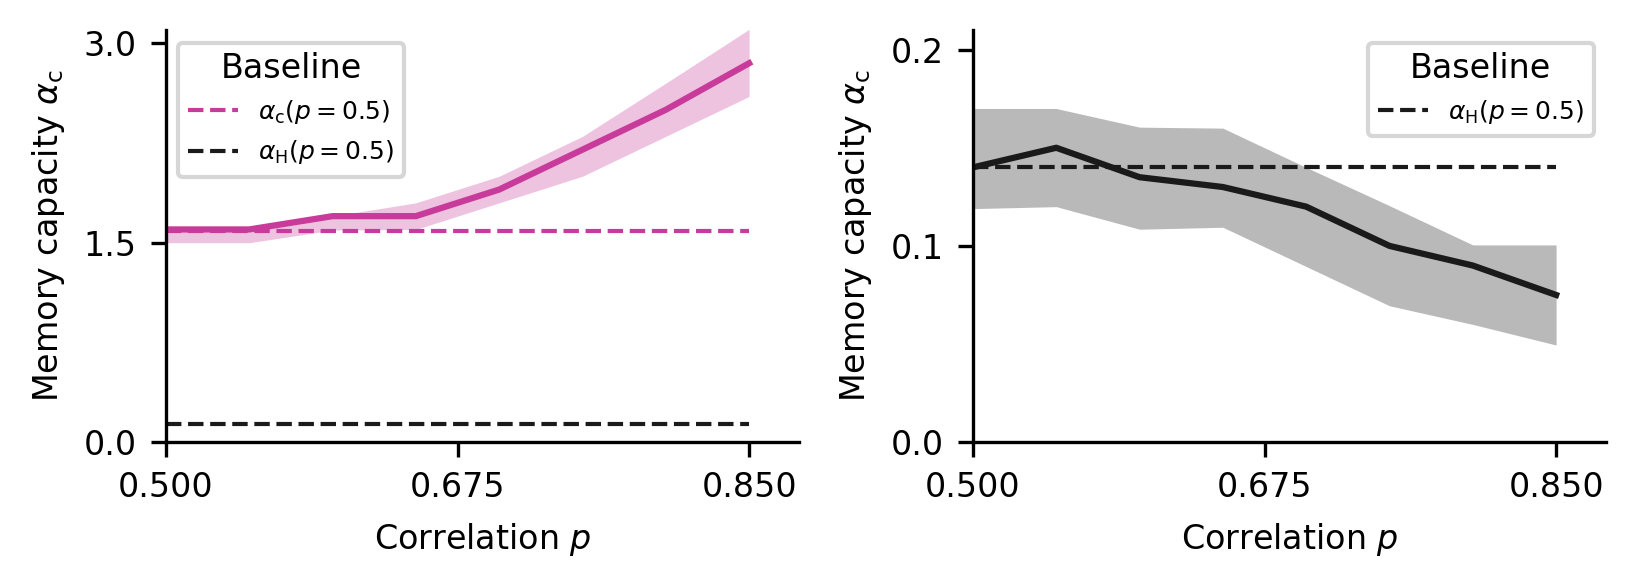

In [4]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(5.5, 2), dpi=300)

# ── Panel A: Infomorphic ─────────────────────────────────────────────────────
ax_a.set_prop_cycle(color=paper_palette[3:4])
ax_a.set_xlabel(r'Correlation $p$')
ax_a.set_ylabel(r'Memory capacity $\alpha_\mathrm{c}$')

plotting.plot_mean_and_area(ax_a, x_corr, alpha_max, quantile=0.9, median=True)
ax_a.hlines([alpha_red], [x_corr[0]], [x_corr[-1]],
            label=r'$\alpha_\mathrm{c}(p=0.5)$', linestyles='--', linewidth=1,
            colors=paper_palette[3:4])
ax_a.hlines([alpha_h], [x_corr[0]], [x_corr[-1]],
            label=r'$\alpha_\mathrm{H}(p=0.5)$', linestyles='--', linewidth=1,
            colors=paper_palette[0:1])

plotting.layout_performance(ax_a, (0.5, 0.85), (0, 3), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0, 0.1))
ax_a.legend(title='Baseline', fontsize=6)
plotting.standard_look(ax_a, ticks=False)

# ── Panel B: Hebbian ─────────────────────────────────────────────────────────
ax_b.set_prop_cycle(color=paper_palette)
ax_b.set_xlabel(r'Correlation $p$')
ax_b.set_ylabel(r'Memory capacity $\alpha_\mathrm{c}$')

plotting.plot_mean_and_area(ax_b, x_corr4, alpha_max4, quantile=0.9, median=True)
ax_b.hlines([alpha_h], [x_corr4[0]], [x_corr4[-1]],
            label=r'$\alpha_\mathrm{H}(p=0.5)$', linestyles='--', linewidth=1,
            colors=paper_palette[0:1])

plotting.layout_performance(ax_b, (0.5, 0.85), (0, 0.2), x_log=False, show_legend=False,
                            border_y=(0, 0.01), border_x=(0, 0.03))
ax_b.legend(title='Baseline', fontsize=6)
plotting.standard_look(ax_b, ticks=False)

# fig.savefig(f"{plot_path}/correlations_combined.svg", bbox_inches='tight')
fig.tight_layout()
plt.show()